C:\Users\farsh\AppData\Local\Temp\ipykernel_344\4112424174.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


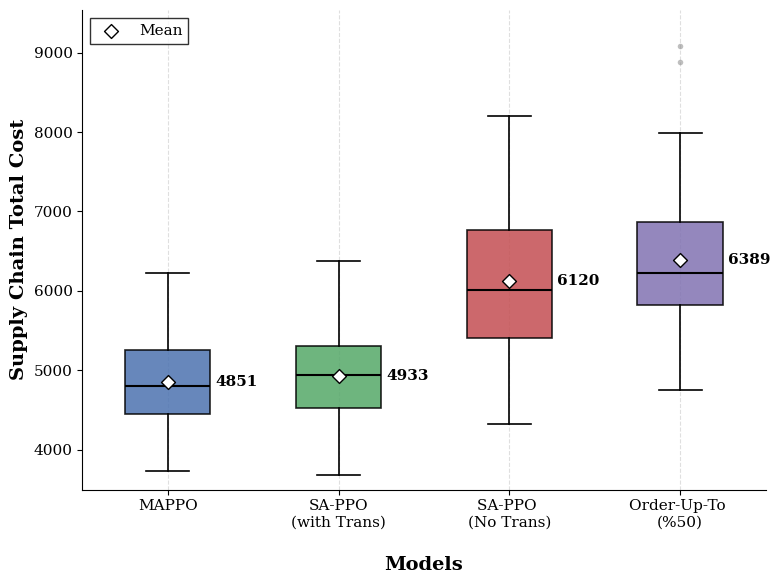

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# General settings for scientific publications
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.figsize": (8, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--"
})

# ==========================================
# File names and model labels
# ==========================================
files = [
    "All Result - MAPPO.xlsx",
    "All Result-SA-T.xlsx",
    "All Result-SA-NT.xlsx",
    "All Result-OUT.xlsx"
]

labels = [
    "MAPPO",
    "SA-PPO\n(with Trans)",
    "SA-PPO \n(No Trans)",
    "Order-Up-To \n(%50)"
]

# ==========================================
# Read data from Excel files
# ==========================================
box_data = []

for file in files:
    df = pd.read_excel(
        file,
        sheet_name="Raw_Episode_Data"
    )

    values = (
        df["SC_Network_Total_Cost"]
        .dropna()
        .values
    )

    box_data.append(values)

# Actual mean value of each method
means = [np.mean(d) for d in box_data]

# ==========================================
# Draw boxplot
# ==========================================
fig, ax = plt.subplots()

bp = ax.boxplot(
    box_data,
    labels=labels,
    patch_artist=True,
    widths=0.5,
    showmeans=False,
    medianprops=dict(
        color="black",
        linewidth=1.5
    ),
    whiskerprops=dict(
        color="black",
        linewidth=1.2
    ),
    capprops=dict(
        color="black",
        linewidth=1.2
    ),
    flierprops=dict(
        marker="o",
        markerfacecolor="gray",
        markeredgecolor="none",
        markersize=4,
        alpha=0.5,
    ),
    boxprops=dict(
        color="black",
        linewidth=1.2
    )
)

# ==========================================
# Box colors
# ==========================================
colors = [
    "#4C72B0",
    "#55A868",
    "#C44E52",
    "#8172B2"
]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# ==========================================
# Display mean values
# ==========================================
ax.scatter(
    range(1, len(means)+1),
    means,
    marker="D",
    color="white",
    edgecolor="black",
    s=50,
    zorder=5,
    label="Mean"
)

for i, m in enumerate(means):
    ax.text(
        i + 1.28,
        m,
        f"{m:.0f}",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# ==========================================
# Figure formatting
# ==========================================
ax.set_ylabel(
    "Supply Chain Total Cost",
    fontweight="bold"
)

ax.set_xlabel(
    "\nModels",
    fontweight="bold"
)

ax.legend(
    loc="upper left",
    frameon=True,
    edgecolor="black",
    fancybox=False
)

ax.grid(axis="y")

# Automatically determine Y-axis limits
global_min = min(np.min(d) for d in box_data)
global_max = max(np.max(d) for d in box_data)

ax.set_ylim(
    global_min * 0.95,
    global_max * 1.05
)

plt.tight_layout()

plt.savefig(
    "network_cost_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Saved image successfully


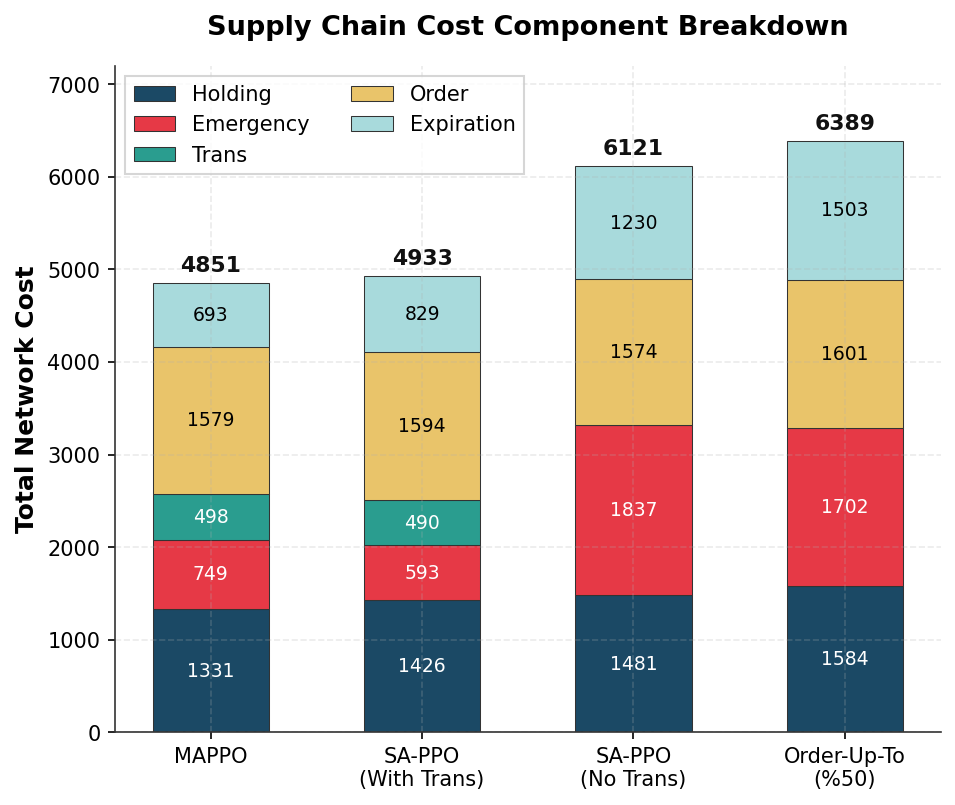

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Set up publication-ready style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
})

# Data from the user (Table 3 - Whole Supply Chain)
models = ['MAPPO', 'SA-PPO\n(With Trans)', 'SA-PPO\n(No Trans)', 'Order-Up-To\n(%50)']
net_total = [4850.76, 4932.64, 6120.87, 6389.39]

# Components for the stacked bar (from Tables 1 and 2, summed for H1+H2)
# H1: Hold, Emerg, Order, Expir
# H2: Hold, Emerg, Order, Expir
# Trans: from Table 3

components = {
    'Holding':   [705.28 + 626.18, 756.82 + 669.35, 742.95 + 737.76, 784.04 + 799.87],
    'Emergency': [235.79 + 513.45, 248.67 + 344.70, 1038.81 + 797.77, 1008.5 + 693],
    'Trans':     [498.12, 489.81, 0.00, 0.00],
    'Order':     [740.67 + 838.50, 823.01 + 771.18, 775.95 + 797.60, 781.96 + 819.32],
    'Expiration':[375.07 + 317.69, 350.20 + 478.91, 617.75 + 612.18, 733.2 + 769.5],
}

comp_colors = ['#1B4965', '#E63946', '#2A9D8F', '#E9C46A', '#A8DADC']
text_colors = ['white', 'white', 'white', 'black', 'black']

fig, ax = plt.subplots(figsize=(6.5, 5.5))
x = np.arange(len(models))
width = 0.55
bottom = np.zeros(len(models))

for i, (name, vals) in enumerate(components.items()):
    bars = ax.bar(x, vals, width, bottom=bottom, label=name,
                  color=comp_colors[i], edgecolor='#333333', linewidth=0.5)
    for j, (b, v) in enumerate(zip(bottom, vals)):
        if v > 250:
            ax.text(j, b + v / 2, f'{v:.0f}', ha='center', va='center',
                    fontsize=9, color=text_colors[i], fontweight='normal')
    bottom += np.array(vals)

for i, total in enumerate(net_total):
    ax.text(i, total + 80, f'{total:.0f}', ha='center', va='bottom',
            fontsize=10.5, fontweight='bold', color='#111111')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('Total Network Cost', fontsize=12, fontweight='bold')
ax.set_title('Supply Chain Cost Component Breakdown', fontsize=13, fontweight='bold', pad=15)

ax.legend(loc='upper left', fontsize=10, ncol=2, frameon=True,
          fancybox=False, edgecolor='#cccccc')
ax.set_ylim(0, 7200)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
print("Saved image successfully")


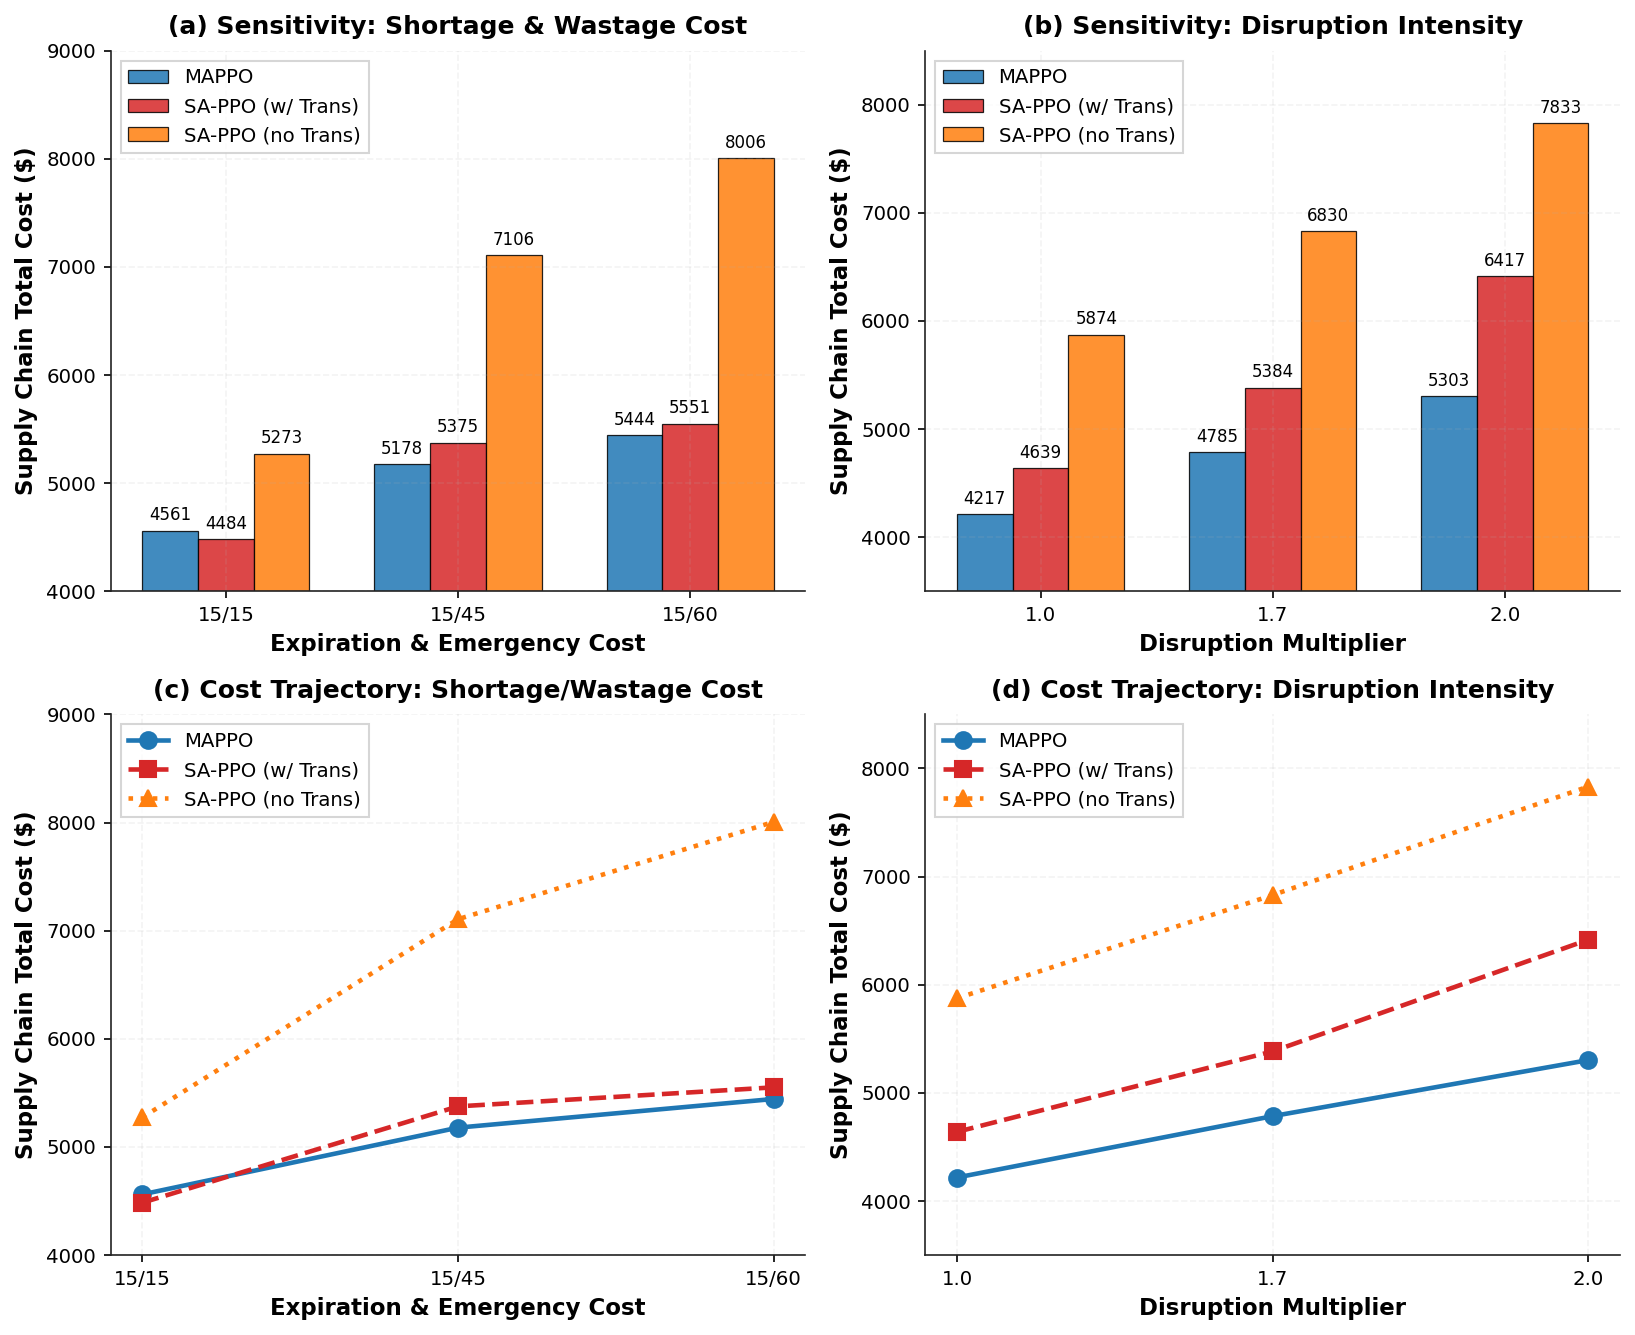

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Publication-ready style
# -------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9.5,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '--',
    'axes.edgecolor': '#222222',
    'axes.linewidth': 0.8,
})

# -------------------------------------------------
# Data
# -------------------------------------------------
scenarios_sw = ['15/15', '15/45', '15/60']
sw_mappo = [4561.24, 5178.41, 5443.76]
sw_sat = [4484.31, 5375.18, 5551.16]
sw_sant = [5272.61, 7105.85, 8006.17]

scenarios_dis = ['1.0', '1.7', '2.0']
dis_mappo = [4217.40, 4784.86, 5303.47]
dis_sat = [4639.38, 5383.83, 6416.92]
dis_sant = [5874.29, 6829.55, 7833.19]

mappo_col = '#1f77b4'
sat_col = '#d62728'
sant_col = '#ff7f0e'

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
width = 0.24

# --- (a) Bar: Shortage/Wastage ---
ax = axes[0, 0]
x = np.arange(len(scenarios_sw))

bars1 = ax.bar(x - width, sw_mappo, width, label='MAPPO', color=mappo_col,
               alpha=0.85, edgecolor='black', linewidth=0.6)
bars2 = ax.bar(x, sw_sat, width, label='SA-PPO (w/ Trans)', color=sat_col,
               alpha=0.85, edgecolor='black', linewidth=0.6)
bars3 = ax.bar(x + width, sw_sant, width, label='SA-PPO (no Trans)', color=sant_col,
               alpha=0.85, edgecolor='black', linewidth=0.6)

ax.set_xlabel('Expiration & Emergency Cost', fontweight='bold')
ax.set_ylabel('Supply Chain Total Cost ($)', fontweight='bold')
ax.set_title('(a) Sensitivity: Shortage & Wastage Cost', fontweight='bold', pad=8)
ax.set_xticks(x)
ax.set_xticklabels(scenarios_sw)
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')
ax.set_ylim(4000, 9000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.0f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

# --- (b) Bar: Disruption ---
ax = axes[0, 1]
x = np.arange(len(scenarios_dis))

bars1 = ax.bar(x - width, dis_mappo, width, label='MAPPO', color=mappo_col,
               alpha=0.85, edgecolor='black', linewidth=0.6)
bars2 = ax.bar(x, dis_sat, width, label='SA-PPO (w/ Trans)', color=sat_col,
               alpha=0.85, edgecolor='black', linewidth=0.6)
bars3 = ax.bar(x + width, dis_sant, width, label='SA-PPO (no Trans)', color=sant_col,
               alpha=0.85, edgecolor='black', linewidth=0.6)

ax.set_xlabel('Disruption Multiplier', fontweight='bold')
ax.set_ylabel('Supply Chain Total Cost ($)', fontweight='bold')
ax.set_title('(b) Sensitivity: Disruption Intensity', fontweight='bold', pad=8)
ax.set_xticks(x)
ax.set_xticklabels(scenarios_dis)
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')
ax.set_ylim(3500, 8500)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.0f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

# --- (c) Line: Shortage/Wastage ---
ax = axes[1, 0]
ax.plot(scenarios_sw, sw_mappo, 'o-', color=mappo_col, linewidth=2.2,
        markersize=8, label='MAPPO')
ax.plot(scenarios_sw, sw_sat, 's--', color=sat_col, linewidth=2.2,
        markersize=8, label='SA-PPO (w/ Trans)')
ax.plot(scenarios_sw, sw_sant, '^:', color=sant_col, linewidth=2.2,
        markersize=8, label='SA-PPO (no Trans)')

ax.set_xlabel('Expiration & Emergency Cost', fontweight='bold')
ax.set_ylabel('Supply Chain Total Cost ($)', fontweight='bold')
ax.set_title('(c) Cost Trajectory: Shortage/Wastage Cost', fontweight='bold', pad=8)
ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='#cccccc')
ax.set_ylim(4000, 9000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- (d) Line: Disruption ---
ax = axes[1, 1]
ax.plot(scenarios_dis, dis_mappo, 'o-', color=mappo_col, linewidth=2.2,
        markersize=8, label='MAPPO')
ax.plot(scenarios_dis, dis_sat, 's--', color=sat_col, linewidth=2.2,
        markersize=8, label='SA-PPO (w/ Trans)')
ax.plot(scenarios_dis, dis_sant, '^:', color=sant_col, linewidth=2.2,
        markersize=8, label='SA-PPO (no Trans)')

ax.set_xlabel('Disruption Multiplier', fontweight='bold')
ax.set_ylabel('Supply Chain Total Cost ($)', fontweight='bold')
ax.set_title('(d) Cost Trajectory: Disruption Intensity', fontweight='bold', pad=8)
ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='#cccccc')
ax.set_ylim(3500, 8500)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

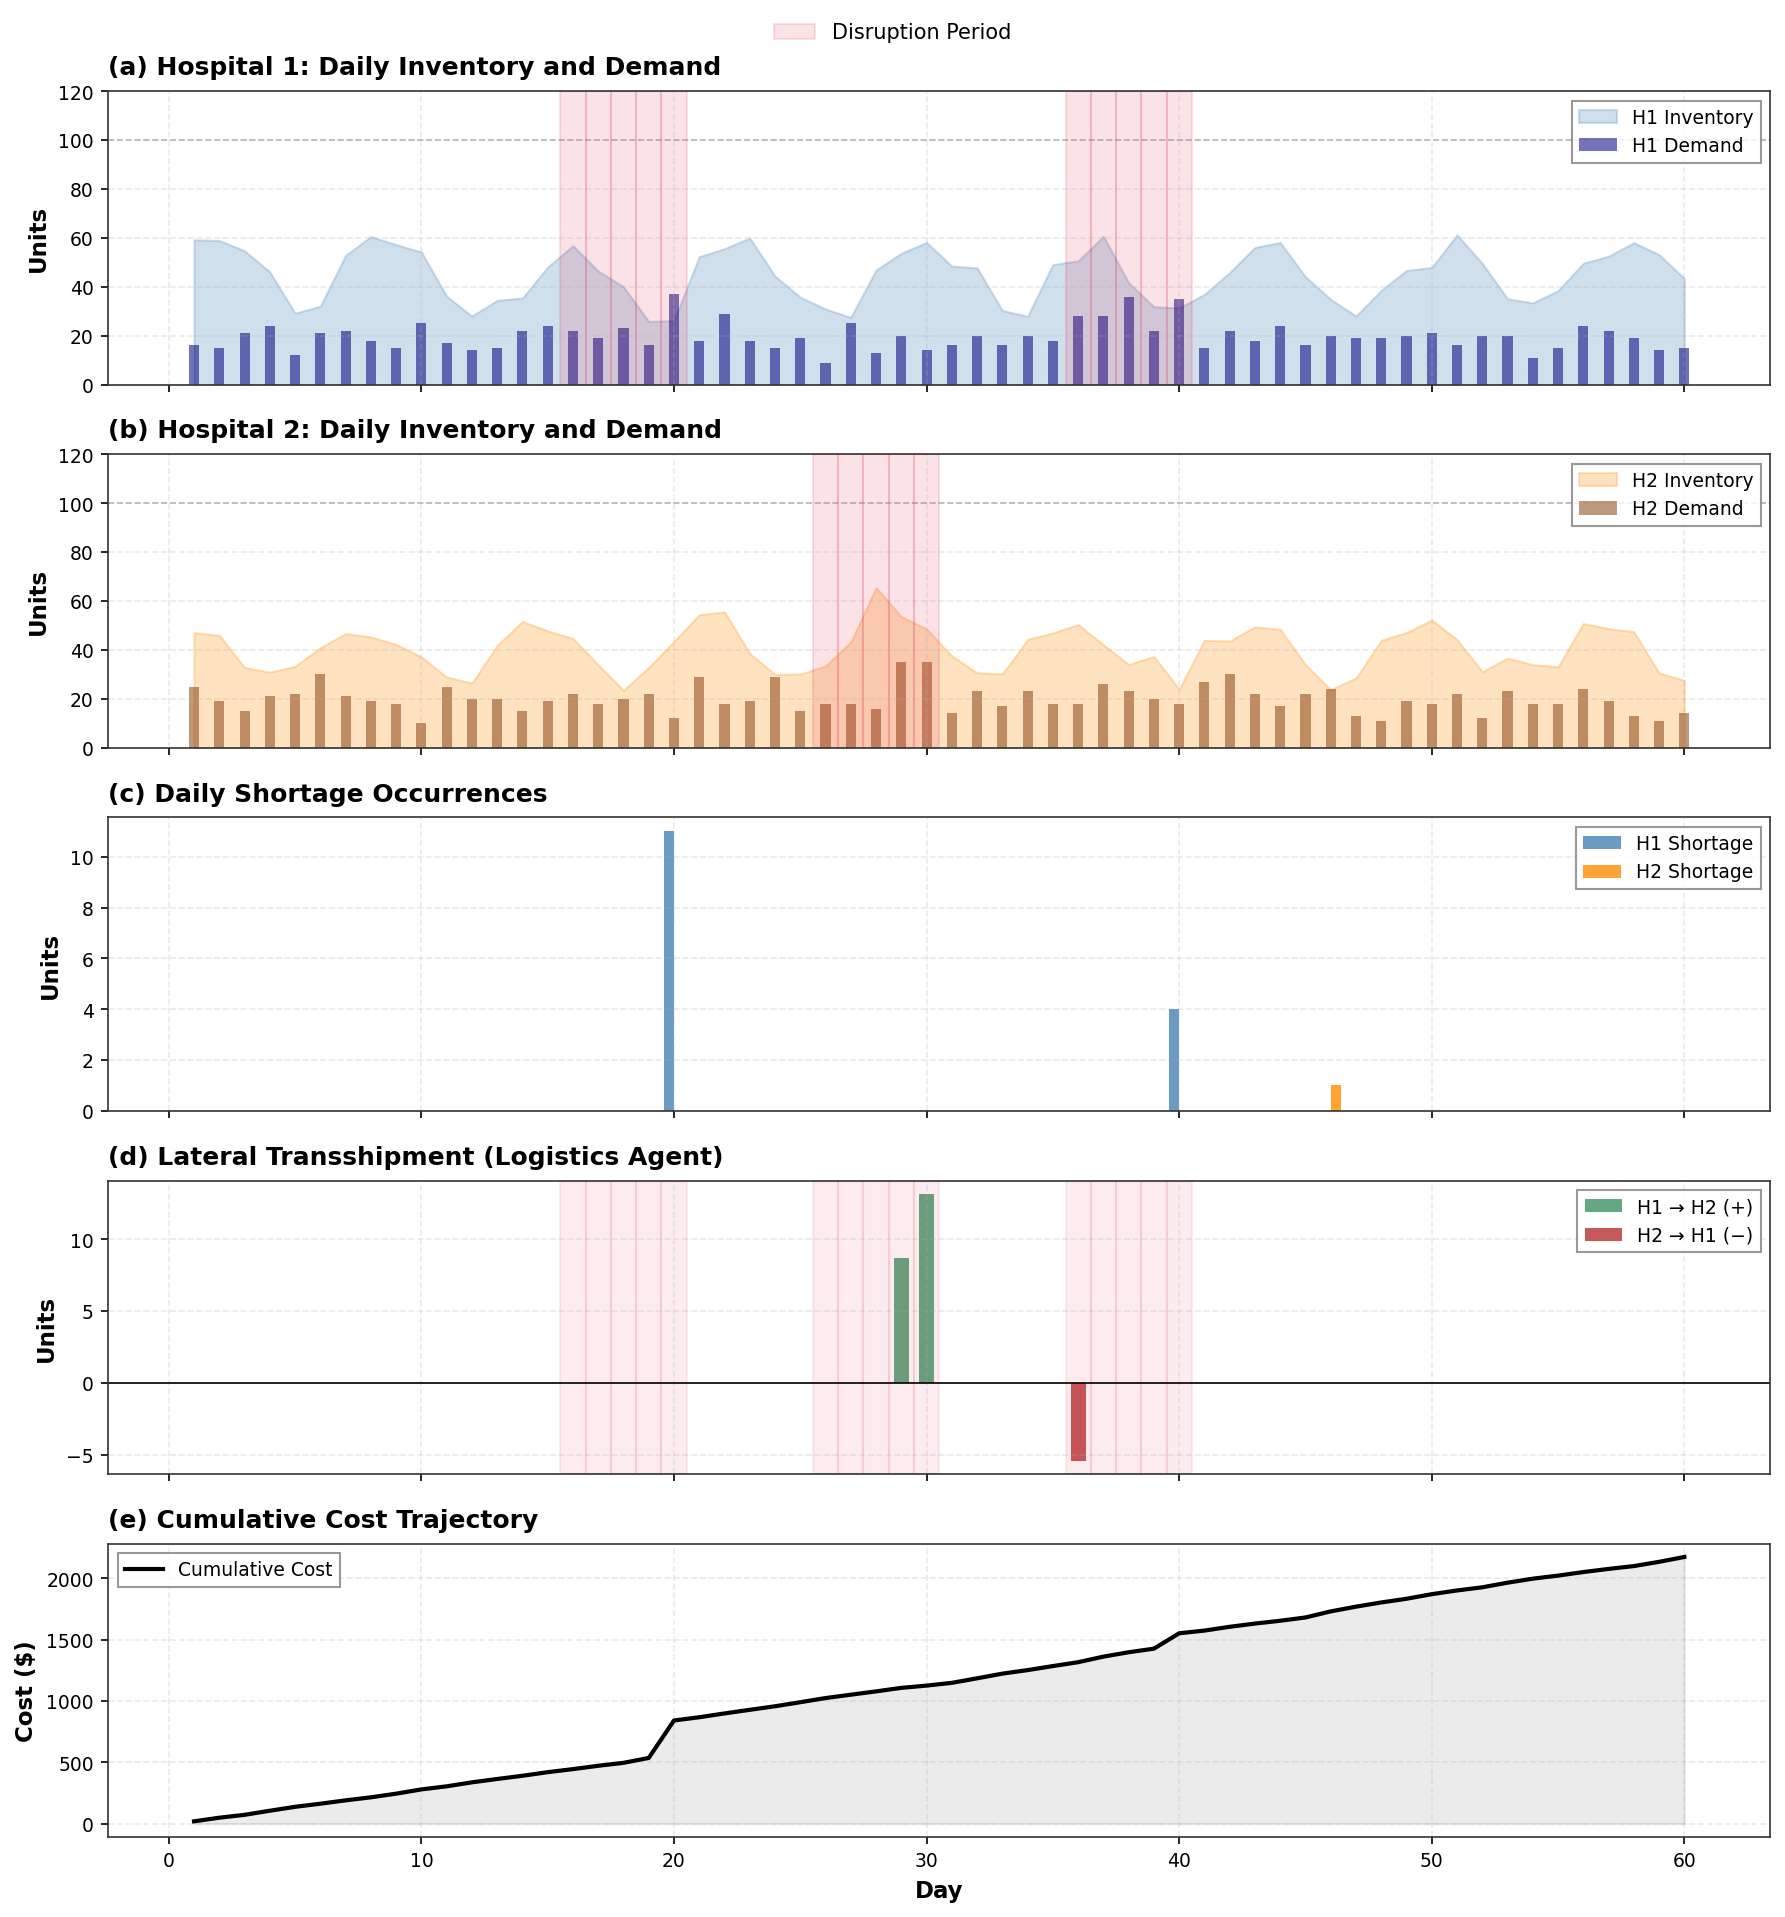

Figure 6 saved.


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# -------------------------------------------------
# Publication-ready style
# -------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
})

# -------------------------------------------------
# Data simulation (one representative episode)
# -------------------------------------------------
np.random.seed(42)
days = np.arange(1, 61)

# H1
inv_h1 = 45 + 15 * np.sin(2 * np.pi * days / 7) + np.random.normal(0, 5, 60)
inv_h1 = np.clip(inv_h1, 5, 95)
demand_h1 = np.random.poisson(18, 60)
disrupt_h1 = np.zeros(60, dtype=bool)
disrupt_h1[15:20] = True
disrupt_h1[35:40] = True
demand_h1[disrupt_h1] = (demand_h1[disrupt_h1] * 1.4).astype(int)

# H2
inv_h2 = 40 + 12 * np.sin(2 * np.pi * days / 7 + 1) + np.random.normal(0, 4, 60)
inv_h2 = np.clip(inv_h2, 5, 95)
demand_h2 = np.random.poisson(20, 60)
disrupt_h2 = np.zeros(60, dtype=bool)
disrupt_h2[25:30] = True
demand_h2[disrupt_h2] = (demand_h2[disrupt_h2] * 1.4).astype(int)

# Orders
order_days_h1 = [(d % 7) in {1, 4, 6} for d in days]
order_days_h2 = [(d % 7) in {0, 3, 5} for d in days]
orders_h1 = np.where(order_days_h1, np.random.uniform(20, 50, 60), 0)
orders_h2 = np.where(order_days_h2, np.random.uniform(20, 50, 60), 0)

# Transshipments
trans_h1_to_h2 = np.zeros(60)
trans_h2_to_h1 = np.zeros(60)
for i in range(60):
    if disrupt_h2[i] and inv_h1[i] > 50:
        trans_h1_to_h2[i] = min(inv_h1[i] - 45, 15)
    if disrupt_h1[i] and inv_h2[i] > 50:
        trans_h2_to_h1[i] = min(inv_h2[i] - 45, 15)

# Shortages & costs
short_h1 = np.maximum(0, demand_h1 - inv_h1.astype(int))
short_h2 = np.maximum(0, demand_h2 - inv_h2.astype(int))
daily_cost = (short_h1 + short_h2) * 25 + np.random.normal(30, 5, 60)
cum_cost = np.cumsum(daily_cost)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True)

# (a) H1 Inventory & Demand
ax = axes[0]
ax.fill_between(days, 0, inv_h1, alpha=0.25, color='steelblue', label='H1 Inventory')
ax.bar(days, demand_h1, width=0.4, color='navy', alpha=0.55, label='H1 Demand')
for i in np.where(disrupt_h1)[0]:
    ax.axvspan(days[i] - 0.5, days[i] + 0.5, alpha=0.12, color='crimson')
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_title('(a) Hospital 1: Daily Inventory and Demand',
             fontweight='bold', loc='left', pad=8)
ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='gray')
ax.set_ylabel('Units', fontweight='bold')
ax.set_ylim(0, 120)

# (b) H2 Inventory & Demand
ax = axes[1]
ax.fill_between(days, 0, inv_h2, alpha=0.25, color='darkorange', label='H2 Inventory')
ax.bar(days, demand_h2, width=0.4, color='saddlebrown', alpha=0.55, label='H2 Demand')
for i in np.where(disrupt_h2)[0]:
    ax.axvspan(days[i] - 0.5, days[i] + 0.5, alpha=0.12, color='crimson')
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_title('(b) Hospital 2: Daily Inventory and Demand',
             fontweight='bold', loc='left', pad=8)
ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='gray')
ax.set_ylabel('Units', fontweight='bold')
ax.set_ylim(0, 120)

# (c) Shortages
ax = axes[2]
ax.bar(days - 0.2, short_h1, width=0.4, color='steelblue',
       alpha=0.8, label='H1 Shortage')
ax.bar(days + 0.2, short_h2, width=0.4, color='darkorange',
       alpha=0.8, label='H2 Shortage')
ax.set_title('(c) Daily Shortage Occurrences',
             fontweight='bold', loc='left', pad=8)
ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='gray')
ax.set_ylabel('Units', fontweight='bold')

# (d) Transshipments
ax = axes[3]
ax.bar(days, trans_h1_to_h2, width=0.6, color='seagreen',
       alpha=0.75, label='H1 → H2 (+)')
ax.bar(days, -trans_h2_to_h1, width=0.6, color='firebrick',
       alpha=0.75, label='H2 → H1 (−)')
ax.axhline(0, color='black', linewidth=0.8)
for i in np.where(disrupt_h1 | disrupt_h2)[0]:
    ax.axvspan(days[i] - 0.5, days[i] + 0.5, alpha=0.08, color='crimson')
ax.set_title('(d) Lateral Transshipment (Logistics Agent)',
             fontweight='bold', loc='left', pad=8)
ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='gray')
ax.set_ylabel('Units', fontweight='bold')

# (e) Cumulative Cost
ax = axes[4]
ax.plot(days, cum_cost, color='black', linewidth=2, label='Cumulative Cost')
ax.fill_between(days, 0, cum_cost, alpha=0.08, color='black')
ax.set_title('(e) Cumulative Cost Trajectory',
             fontweight='bold', loc='left', pad=8)
ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='gray')
ax.set_xlabel('Day', fontweight='bold')
ax.set_ylabel('Cost ($)', fontweight='bold')

# Global disruption legend
red_patch = mpatches.Patch(color='crimson', alpha=0.12, label='Disruption Period')
fig.legend(handles=[red_patch], loc='upper center', bbox_to_anchor=(0.5, 0.985),
           ncol=1, fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
print("Figure 6 saved.")

# Distribution

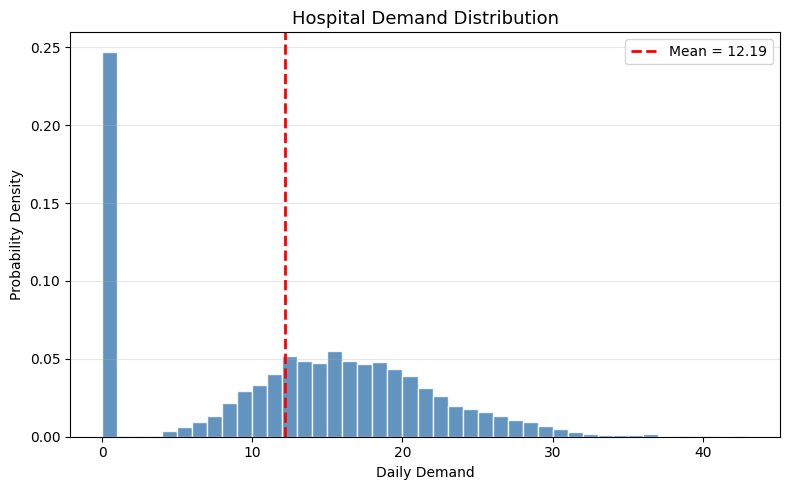

Hospital Demand — Mean: 12.32 | Std: 8.71 | Max: 42


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# Parameters and helper functions
# =============================================================================
ZINB_H1_PARAMS = [{"phi": 0.25, "p": 0.48, "n": 15}]
ZINB_H2_PARAMS = [{"phi": 0.25, "p": 0.48, "n": 15}]

def sample_zinb(phi: float, p: float, n: int) -> int:
    if np.random.random() < phi:
        return 0
    return int(np.random.negative_binomial(n, p))

def sample_hospital_demand(zinb_params: list, mult: float = 1.0) -> int:
    total = sum(sample_zinb(p["phi"], p["p"], p["n"]) for p in zinb_params)
    return max(0, int(total * mult))

def _zinb_mean(params: dict) -> float:
    phi, p, n = params["phi"], params["p"], params["n"]
    return (1.0 - phi) * n * (1.0 - p) / p

# =============================================================================
# Generate random demand samples
# =============================================================================
N_SAMPLES = 5_000  # Number of samples for a smoother histogram

demands_h1 = [
    sample_hospital_demand(ZINB_H1_PARAMS, mult=1.0)
    for _ in range(N_SAMPLES)
]

# Calculate theoretical mean demand
mean_h1 = sum(_zinb_mean(p) for p in ZINB_H1_PARAMS)

# =============================================================================
# Plot hospital demand histogram
# =============================================================================
plt.figure(figsize=(8, 5))

plt.hist(
    demands_h1,
    bins=range(0, max(demands_h1) + 2),
    color='steelblue',
    edgecolor='white',
    alpha=0.85,
    density=True
)

plt.axvline(
    mean_h1,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_h1:.2f}'
)

plt.title('Hospital Demand Distribution', fontsize=13)
plt.xlabel('Daily Demand')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hospital_demand_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# Print descriptive statistics
# =============================================================================
print(
    f"Hospital Demand — "
    f"Mean: {np.mean(demands_h1):.2f} | "
    f"Std: {np.std(demands_h1):.2f} | "
    f"Max: {np.max(demands_h1)}"
)